# ecDNAInspector: analysis module

This notebook enables analysis of your cohort ecDNA data. There are modules for:
- **basic analysis of full cohort** (or confidence group subset)
- **pairwise Jaccard metric analysis** (cycle conservation analysis) 
- **single cycle versus cohort comparison analysis** (for numeric cycle metrics)
- **subgroup analysis** (e.g. for clinical subtypes, patient demographic groups, etc)

In [3]:
import numpy as np
import pandas as pd

%run 'ecDNAInspector_functions.ipynb'
print("ecDNAInspector functions loaded!")

# note - if you receive an error about NumPy 1.x, this is okay - numpy 1.24 is required for the clustering portion, which is not needed here.

ecDNAInspector functions loaded!


In [4]:
# Some code requires seaborn v0.12.2 or higher - make sure it is updated! After updating, restart the kernel to confirm changes.
!pip install --upgrade seaborn

In [5]:
print(pd.__version__)
print(sns.__version__)

2.2.2
0.13.2


## **Load cycle level data tables**

In [6]:
# replace with the path to your cycle-level data table (with confidence information)
cycle_level_data_path = 'subset_tool_testing/testing_intrasample_filt_cycle_data_w_conf.csv'
cohort_df = pd.read_csv(cycle_level_data_path)

# replace with the path to your Jaccard table
cycle_jacc_data_path = 'subset_tool_testing/testing_full_cohort_jacc_data.csv'
cycle_jacc_df = pd.read_csv(cycle_jacc_data_path)

# replace with the path to your subgroup information file
# NOTE: this is not necessary if you want to group by one of the categorical variables already present in cohort_df (e.g. Confidence)
group_data_path = 'subset_tool_testing/testing_group_info.csv'
group_df = pd.read_csv(group_data_path)

## **Jaccard dataframes preprocessing**

In [7]:
# OPTIONAL - remove same-sample comparisons. Comment out line if you prefer to keep intra-sample comparisons.
cycle_jacc_df = cycle_jacc_df[cycle_jacc_df["Sample1"] != cycle_jacc_df["Sample2"]]

cycle_jacc_conf_df = cycle_jacc_df.merge(cohort_df[["Sample", "Amplicon", "Cycle", "Confidence"]], left_on=['Sample1', 'Amp1', 'Cycle1'], right_on=['Sample', 'Amplicon', 'Cycle'], how='left')
cycle_jacc_conf_df = cycle_jacc_conf_df.drop(["Sample", "Amplicon", "Cycle"], axis=1)
cycle_jacc_conf_df = cycle_jacc_conf_df.rename(columns={"Confidence": "Confidence1"})

cycle_jacc_conf_df = cycle_jacc_conf_df.merge(cohort_df[["Sample", "Amplicon", "Cycle", "Confidence"]], left_on=['Sample2', 'Amp2', 'Cycle2'], right_on=['Sample', 'Amplicon', 'Cycle'], how='left')
cycle_jacc_conf_df = cycle_jacc_conf_df.drop(["Sample", "Amplicon", "Cycle"], axis=1)
cycle_jacc_conf_df = cycle_jacc_conf_df.rename(columns={"Confidence": "Confidence2"})

## **Basic analysis of full cohort**

### Set up the different confidence group data frames.
##### *analysis can be done with the full cohort, or any of these subsets.*

In [8]:
hc_cohort_df = cohort_df[cohort_df["Confidence"] == "high"]
mc_cohort_df = cohort_df[cohort_df["Confidence"] == "medium"]
lc_cohort_df = cohort_df[cohort_df["Confidence"] == "low"]

### Plot cohort cycle metric histogram.

#### Example 1: Cycle TPR (high confidence cycles only)

Mean: 0.8078742608154371
Median: 0.8333333333333334


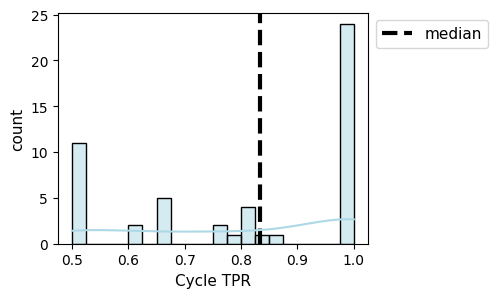

In [9]:
# replace with your preferred subset or the full cohort_df
data_df = hc_cohort_df

# replace with any numeric metric from your cohort_df
metric = "Cycle TPR"

### histogram visualization preferences

# number of bins in histogram
bin_count = 20
# if True, shows estimated probability density curve
show_kde = True
# options: count, density (area under bars = 1), probability (sum of bar heights = 1)
stat_type = "count"

plot_cohort_histogram(data_df, metric, bin_count, show_kde, stat_type)

#### Example 2: Cycle Size (bp) (all confidence groups)

Mean: 792857.3716216217
Median: 303243.5


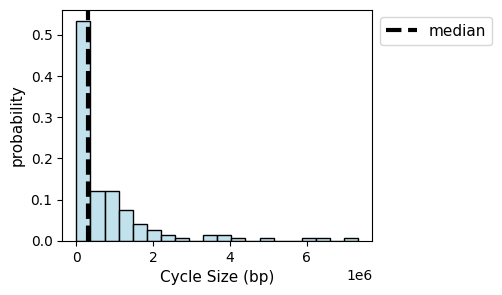

In [10]:
# replace with your preferred subset or the full cohort_df
data_df = cohort_df

# replace with any numeric metric from your cohort_df
metric = "Cycle Size (bp)"

### histogram visualization preferences

# number of bins in histogram
bin_count = 20
# if True, shows estimated probability density curve
show_kde = False
# options: count, density (area under bars = 1), probability (sum of bar heights = 1)
stat_type = "probability"

plot_cohort_histogram(data_df, metric, bin_count, show_kde, stat_type)

### Plot cohort cycle chromosome contributions barplot.

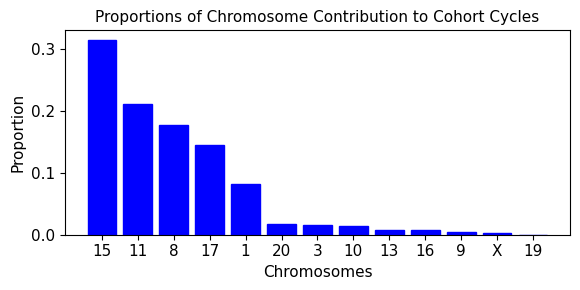

In [11]:
# replace with your preferred subset or the full cohort_df
data_df = hc_cohort_df

plot_cohort_chrom_contribution(data_df)

## **Pairwise Jaccard metric analysis**

### Set up the different confidence group data frames.
##### *analysis can be done with the full cohort, or any of these subsets.*

In [12]:
cycle_jacc_HC_df = cycle_jacc_conf_df[(cycle_jacc_conf_df["Confidence1"] == "high") & (cycle_jacc_conf_df["Confidence2"] == "high")]
cycle_jacc_MC_df = cycle_jacc_conf_df[(cycle_jacc_conf_df["Confidence1"] == "medium") & (cycle_jacc_conf_df["Confidence2"] == "medium")]
cycle_jacc_LC_df = cycle_jacc_conf_df[(cycle_jacc_conf_df["Confidence1"] == "low") & (cycle_jacc_conf_df["Confidence2"] == "low")]

### Plot maximum pairwise Jaccard metric heatmap.

#### Example 1: Maximum basepair Jaccard values (all confidence groups)

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/138373833.py:23: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  row_linkage = sch.linkage(combined, method='average')
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/138373833.py:24: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  col_linkage = sch.linkage(combined.T, method='average')


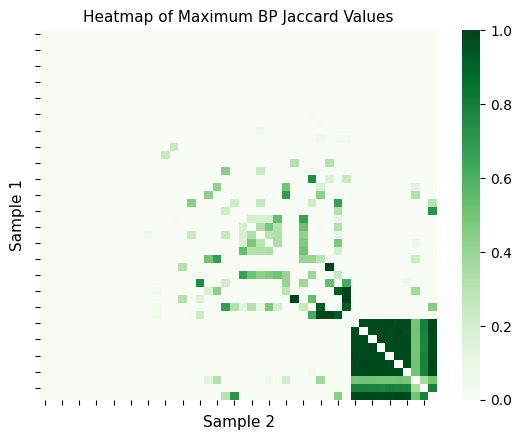

In [13]:
# replace with your preferred subset or the full cohort_df
jaccard_data_df = cycle_jacc_df

# replace with BP Jaccard, Gene Jaccard, or Breakend Jaccard
jaccard_metric = "BP Jaccard"

plot_cohort_jacc_heatmap(jaccard_data_df, jaccard_metric, show_labels = False)

#### Example 2: Maximum gene Jaccard values (high confidence cycles)

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/138373833.py:23: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  row_linkage = sch.linkage(combined, method='average')
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/138373833.py:24: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  col_linkage = sch.linkage(combined.T, method='average')


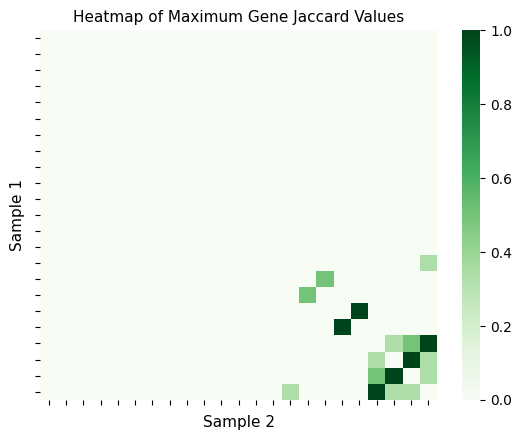

In [14]:
# replace with your preferred subset or the full cohort_df
jaccard_data_df = cycle_jacc_HC_df

# replace with BP Jaccard, Gene Jaccard, or Breakend Jaccard
jaccard_metric = "Gene Jaccard"

plot_cohort_jacc_heatmap(jaccard_data_df, jaccard_metric, show_labels = False)

#### Example 2: Maximum gene Jaccard values (low confidence cycles)

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/138373833.py:23: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  row_linkage = sch.linkage(combined, method='average')
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/138373833.py:24: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  col_linkage = sch.linkage(combined.T, method='average')


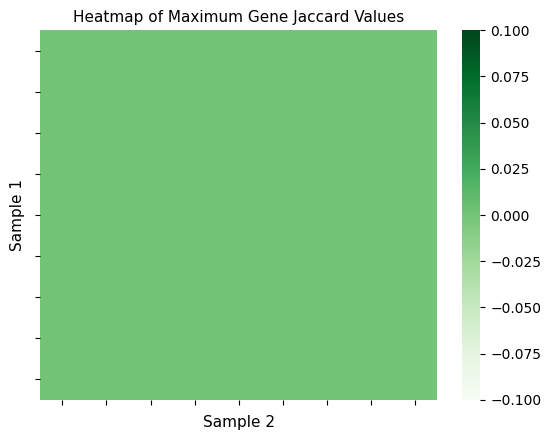

In [15]:
# replace with your preferred subset or the full cohort_df
jaccard_data_df = cycle_jacc_LC_df

# replace with BP Jaccard, Gene Jaccard, or Breakend Jaccard
jaccard_metric = "Gene Jaccard"

plot_cohort_jacc_heatmap(jaccard_data_df, jaccard_metric, show_labels = False)

### Specific pair Jaccard metric comparison

##### Cycle 1:

In [18]:
sample_1 = 'CURTIS_H000512_T01_01_WG01'
amplicon_1 = 1
cycle_1 = 13

cycle_1_name = sample_1 + ", amp " + str(amplicon_1) + ", cycle " + str(cycle_1)

cycle_1_row = cohort_df[(cohort_df['Sample'] == sample_1) & (cohort_df['Amplicon'] == amplicon_1) & (cohort_df['Cycle'] == cycle_1)]

cycle_1_row

,Sample,Amplicon,Cycle,Cycle Type,Cycle Size (bp),Cycle Breakpoint Count,Cycle Chromosome Count,Cycle Regions List,Cycle Paired Ends List,Cycle TPR,...,Cycle Mapping Error Breakends,Cycle Unmappable Reasons,Small Deletions Count,Cycle Genes Info,Cycle Genes List,Cycle ESB,Cycle Type Boolean,Cycle Cluster Assignment,Confidence,Selection Score
41,CURTIS_H000512_T01_01_WG01,1,13,linear,564,1,1,"[('17', 30277243, 30276678)]","[('17', 30276678, '17', 30277243)]",0.0,...,"[('17', 30276678), ('17', 30277243)]","['High_Signal_Region', 'High_Signal_Region']",0,{},[],0.0,0,2,low,2.0625


##### Cycle 2:

In [19]:
sample_2 = 'CURTIS_H000505_T01_01_WG01'
amplicon_2 = 2
cycle_2 = 4

cycle_2_name = sample_2 + ", amp " + str(amplicon_2) + ", cycle " + str(cycle_2)

cycle_2_row = cohort_df[(cohort_df['Sample'] == sample_2) & (cohort_df['Amplicon'] == amplicon_2) & (cohort_df['Cycle'] == cycle_2)]

cycle_2_row

,Sample,Amplicon,Cycle,Cycle Type,Cycle Size (bp),Cycle Breakpoint Count,Cycle Chromosome Count,Cycle Regions List,Cycle Paired Ends List,Cycle TPR,...,Cycle Mapping Error Breakends,Cycle Unmappable Reasons,Small Deletions Count,Cycle Genes Info,Cycle Genes List,Cycle ESB,Cycle Type Boolean,Cycle Cluster Assignment,Confidence,Selection Score
20,CURTIS_H000505_T01_01_WG01,2,4,linear,523,1,1,"[('17', 30277202, 30276678)]","[('17', 30276678, '17', 30277202)]",0.0,...,"[('17', 30276678), ('17', 30277202)]","['High_Signal_Region', 'High_Signal_Region']",0,{},[],1.0,0,2,low,2.4375


##### Cycle pair information:

In [20]:
pair_row = cycle_jacc_df[((cycle_jacc_df["Sample1"] == sample_1) & (cycle_jacc_df["Amp1"] == amplicon_1) & 
                          (cycle_jacc_df["Cycle1"] == cycle_1) & (cycle_jacc_df["Sample2"] == sample_2) & 
                          (cycle_jacc_df["Amp2"] == amplicon_2) & (cycle_jacc_df["Cycle2"] == cycle_2)) | 
                         ((cycle_jacc_df["Sample1"] == sample_2) & (cycle_jacc_df["Amp1"] == amplicon_2) & 
                          (cycle_jacc_df["Cycle1"] == cycle_2) & (cycle_jacc_df["Sample2"] == sample_1) &
                          (cycle_jacc_df["Amp2"] == amplicon_1) & (cycle_jacc_df["Cycle2"] == cycle_1))]

pair_row

,Sample1,Amp1,Cycle1,Sample2,Amp2,Cycle2,BP Jaccard,Gene Jaccard,Overlapping Genes,Breakend Jaccard,Overlapping Breakends
6578,CURTIS_H000512_T01_01_WG01,1,13,CURTIS_H000505_T01_01_WG01,2,4,0.927562,0.0,[],1.0,"[('17', 30276678, 30276678), ('17', 30277243, ..."


## **Single cycle versus full cohort comparison analysis**

### Input cycle of interest information.

In [22]:
sample_OI = 'CURTIS_H000400_T01_01_WG01'
amplicon_OI = 1
cycle_OI = 1

cycle_OI_name = sample_OI + ", amp " + str(amplicon_OI) + ", cycle " + str(cycle_OI)

cycle_OI_row = cohort_df[(cohort_df['Sample'] == sample_OI) & (cohort_df['Amplicon'] == amplicon_OI) & (cohort_df['Cycle'] == cycle_OI)]

cycle_OI_row

,Sample,Amplicon,Cycle,Cycle Type,Cycle Size (bp),Cycle Breakpoint Count,Cycle Chromosome Count,Cycle Regions List,Cycle Paired Ends List,Cycle TPR,...,Cycle Mapping Error Breakends,Cycle Unmappable Reasons,Small Deletions Count,Cycle Genes Info,Cycle Genes List,Cycle ESB,Cycle Type Boolean,Cycle Cluster Assignment,Confidence,Selection Score
0,CURTIS_H000400_T01_01_WG01,1,1,circular,866099,2,1,"[('17', 57919191, 58411914), ('17', 58414024, ...","[('17', 58411914, '17', 58414024), ('17', 5878...",0.5,...,[],[],0,"{'17': {'PPM1D': {'type': ['oncogene'], 'loc':...",['PPM1D'],0.0,1,0,high,0.5


## Plot single cycle metric versus cohort metric distribution.

#### Example 1: Cycle Size (bp) (high confidence cycles)

p = 0.3921568627450981


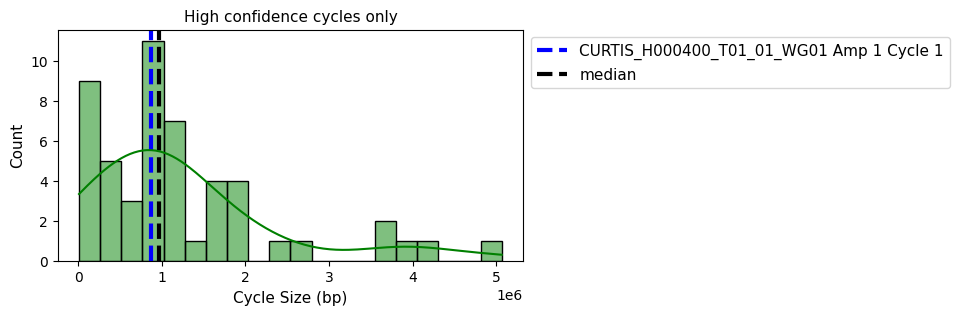

In [23]:
# replace with your preferred subset or the full cohort_df
data_df = hc_cohort_df
target_sample, target_amp, target_cycle = sample_OI, amplicon_OI, cycle_OI
# replace with any numeric metric from your cohort_df
metric = "Cycle Size (bp)"

# if setting this to true, make sure to use the full cohort_df (will plot histograms for all three confidence groups on the same plot)
split_by_confidence = False

### histogram visualization preferences
# number of bins in histogram
bin_count = 20
# if True, shows estimated probability density curve
show_kde = True
# options: count, density (area under bars = 1), probability (sum of bar heights = 1)
stat_type = "count"
fig_size = (6, 3)

# replace depending on which cycle subset you use
fig_title = 'High confidence cycles only'
default_color = 'green'

cycle_v_distribution_p(cycle_OI_row[metric].values, data_df[metric].values, "less")

plot_single_cycle_distribution(data_df, target_sample, target_amp, target_cycle, metric, bin_count, show_kde, stat_type, fig_size, fig_title, default_color, split_by_confidence)

#### Example 2: Cycle Breakpoint Count (all confidence groups)

p = 0.75


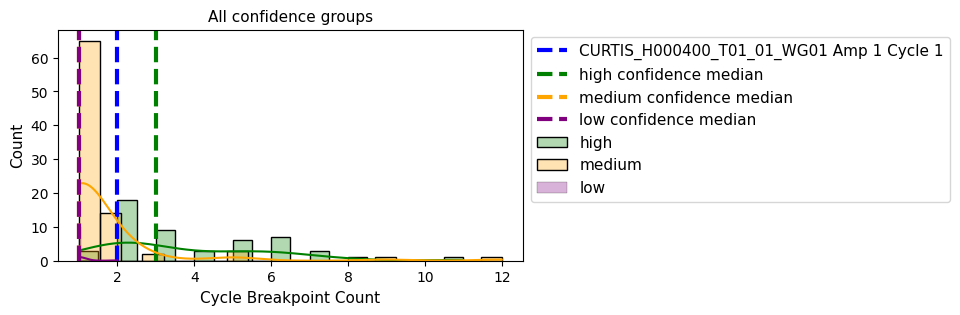

In [24]:
# replace with your preferred subset or the full cohort_df
data_df = cohort_df
target_sample, target_amp, target_cycle = sample_OI, amplicon_OI, cycle_OI
# replace with any numeric metric from your cohort_df
metric = "Cycle Breakpoint Count"

# if setting this to true, make sure to use the full cohort_df (will plot histograms for all three confidence groups on the same plot)
split_by_confidence = True

### histogram visualization preferences
# number of bins in histogram
bin_count = 20
# if True, shows estimated probability density curve
show_kde = True
# options: count, density (area under bars = 1), probability (sum of bar heights = 1)
stat_type = "count"
fig_size = (6, 3)

# replace depending on which cycle subset you use
fig_title = 'All confidence groups'
default_color = 'green'

cycle_v_distribution_p(cycle_OI_row[metric].values, data_df[metric].values, "less")

plot_single_cycle_distribution(data_df, target_sample, target_amp, target_cycle, metric, bin_count, show_kde, stat_type, fig_size, fig_title, default_color, split_by_confidence)

## **Subgroup analysis**

### Set up the subgroup & cycle data merged dataframe.

##### If the categorical variable you want to group by is already present in cohort_df, run this:

In [25]:
full_cohort_group_df = cohort_df

##### If you loaded additional subgroup data in the beginning and need to add it to your cohort_df data, run this:

In [26]:
# replace with the name of the column you would like to group by
group = 'ENiClust'

# replace with the x-axis ordering of groups you prefer
group_order = ["ic1", "ic2", "ic6", "ic9", "ic5", "ic4", "ic10"]

# merge full cohort df with group labels df
full_cohort_group_df = pd.merge(cohort_df, group_df[['Sample', group]], on='Sample', how='left')

### Set up the different confidence group data frames.
##### *analysis can be done with the full cohort, or any of these subsets.*

In [27]:
HC_cohort_group_df = full_cohort_group_df[full_cohort_group_df["Confidence"] == "high"]
MC_cohort_group_df = full_cohort_group_df[full_cohort_group_df["Confidence"] == "medium"]
LC_cohort_group_df = full_cohort_group_df[full_cohort_group_df["Confidence"] == "low"]

### Plot categorical cycle metric by subgroup.

#### Example 1 : Cycle Confidence Assignment by IC subtype (all cycles)

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/3351709562.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_sizes = group_analysis_df.groupby(group).size()
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/3351709562.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proportions = group_analysis_df.groupby(group)[metric].value_counts(normalize=True).unstack(fill_value=0)


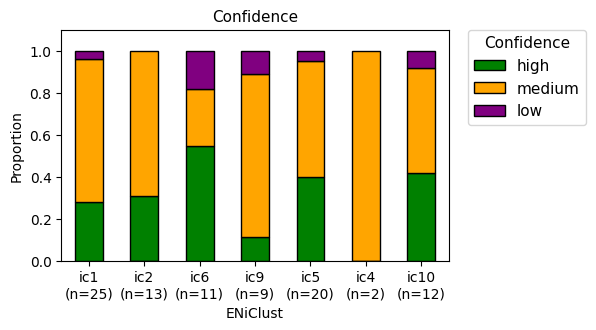

Chi-squared Test of Independence:
  Chi² = 11.8470, df = 12, p = 4.5805e-01
  Cramér's V = 0.2537


In [28]:
# replace with your preferred subset or the full cohort_df
data_df = full_cohort_group_df

# select a categorical metric from the cohort_df 
metric = "Confidence"

# replace with the name of the column you would like to group by
group = 'ENiClust'

# replace with the x-axis ordering of groups you prefer
group_order = ["ic1", "ic2", "ic6", "ic9", "ic5", "ic4", "ic10"]
data_df[group] = pd.Categorical(data_df[group], categories=group_order, ordered=True)

# choose colors for metrics: adjust count and value of metrics according to values for metric in full_cohort_group_df
metric_colors = {"high": 'green', "medium": 'orange', "low": 'purple'}

# choose order for metrics: adjust count and value of metrics according to values for metric in full_cohort_group_df
metric_order = ["high", "medium", "low"]

plot_prop_metric_by_group_barplot(data_df, group, metric, colors = metric_colors, metric_order=metric_order)

#### Example 2 : Cycle Type Boolean by IC Subtype (high confidence cycles only)

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/2015742865.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_df[group] = pd.Categorical(data_df[group], categories=group_order, ordered=True)
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/3351709562.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_sizes = group_analysis_df.groupby(group).size()
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/3351709562.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to T

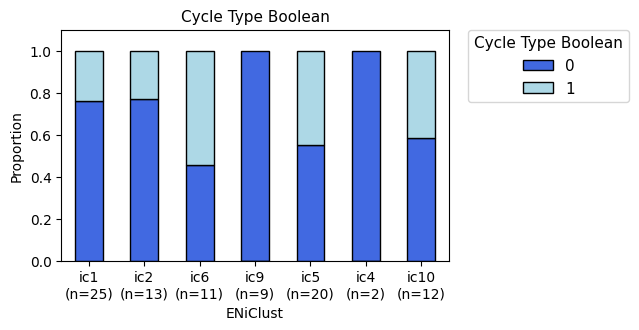

Chi-squared Test of Independence:
  Chi² = 11.1050, df = 6, p = 8.5186e-02
  Cramér's V = 0.3474


In [29]:
# replace with your preferred subset or the full cohort_df
data_df = HC_cohort_group_df

# select a categorical metric from the cohort_df 
metric = "Cycle Type Boolean"

# replace with the name of the column you would like to group by
group = 'ENiClust'

# replace with the x-axis ordering of groups you prefer
group_order = ["ic1", "ic2", "ic6", "ic9", "ic5", "ic4", "ic10"]
data_df[group] = pd.Categorical(data_df[group], categories=group_order, ordered=True)

# choose colors for metrics: adjust count and value of metrics according to values for metric in full_cohort_group_df
metric_colors = {0: 'royalblue', 1: 'lightblue'}

# choose order for metrics: adjust count and value of metrics according to values for metric in full_cohort_group_df
metric_order = [0, 1]

plot_prop_metric_by_group_barplot(full_cohort_group_df, group, metric, colors = metric_colors, metric_order=metric_order)

#### Example 3 : Cycle Type Boolean by Confidence Group

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/3351709562.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_sizes = group_analysis_df.groupby(group).size()
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/3351709562.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proportions = group_analysis_df.groupby(group)[metric].value_counts(normalize=True).unstack(fill_value=0)


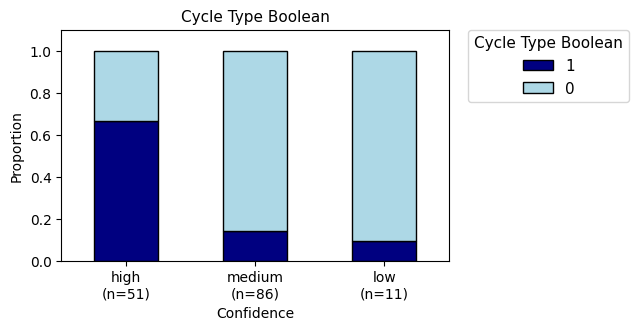

Chi-squared Test of Independence:
  Chi² = 43.8648, df = 2, p = 2.9845e-10
  Cramér's V = 0.5444


In [30]:
# replace with your preferred subset or the full cohort_df
data_df = full_cohort_group_df

# select a categorical metric from the cohort_df 
metric = "Cycle Type Boolean"

# replace with the name of the column you would like to group by
group = 'Confidence'

# replace with the x-axis ordering of groups you prefer
group_order = ["high", "medium", "low"]
data_df[group] = pd.Categorical(data_df[group], categories=group_order, ordered=True)

# choose colors for metrics: adjust count and value of metrics according to values for metric in full_cohort_group_df
metric_colors = {0: 'lightblue', 1: 'navy'}

# choose order for metrics: adjust count and value of metrics according to values for metric in full_cohort_group_df
metric_order = [1, 0]

plot_prop_metric_by_group_barplot(data_df, group, metric, colors = metric_colors, metric_order=metric_order)

### Plot numeric cycle metric by subgroup.

#### Example 1 : Cycle Size (bp) by IC Subtype (all confidence groups)

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/3569055032.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/3569055032.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels, rotation=0, ha='center')


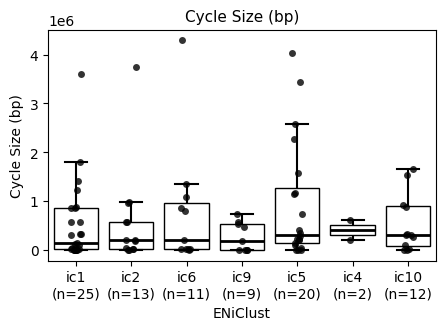

Kruskal-Wallis test:
  H = 3.7084, p = 7.1607e-01, eta² = -0.0270


In [31]:
# replace with your preferred subset or the full cohort_df
data_df = full_cohort_group_df

# select a numeric metric from the cohort_df 
metric = "Cycle Size (bp)"

# replace with the name of the column you would like to group by
group = 'ENiClust'

# replace with the x-axis ordering of groups you prefer
group_order = ["ic1", "ic2", "ic6", "ic9", "ic5", "ic4", "ic10"]
data_df[group] = pd.Categorical(data_df[group], categories=group_order, ordered=True)

plot_group_comp_jitterplot(data_df, group, metric, group_order)

#### Example 2 : Cycle Size (bp) by IC Subtype (high confidence cycles)

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/2008513361.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_df[group] = pd.Categorical(data_df[group], categories=group_order, ordered=True)
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/3569055032.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_analysis_df[group] = pd.Categorical(group_analysis_df[group], categories=group_order, ordered=True)
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_539

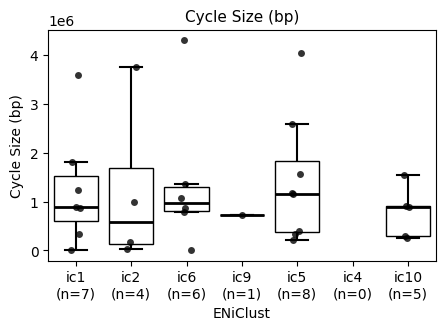

Kruskal-Wallis test:
  H = 1.4913, p = 9.1408e-01, eta² = -0.1403


In [32]:
# replace with your preferred subset or the full cohort_df
data_df = HC_cohort_group_df

# select a numeric metric from the cohort_df 
metric = "Cycle Size (bp)"

# replace with the name of the column you would like to group by
group = 'ENiClust'

# replace with the x-axis ordering of groups you prefer
group_order = ["ic1", "ic2", "ic6", "ic9", "ic5", "ic4", "ic10"]
data_df[group] = pd.Categorical(data_df[group], categories=group_order, ordered=True)

plot_group_comp_jitterplot(data_df, group, metric, group_order)

#### Example 3: Cycle Size (bp) by Confidence Group

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/3569055032.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_53947/3569055032.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels, rotation=0, ha='center')


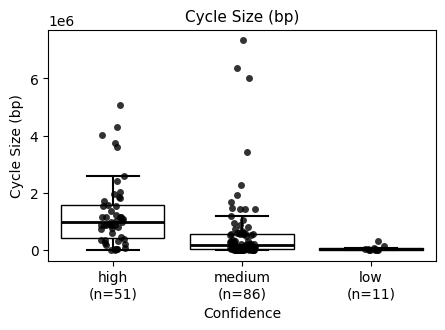

Kruskal-Wallis test:
  H = 38.1058, p = 5.3141e-09, eta² = 0.2490

Dunn's pairwise p-values (Bonferroni-corrected):
                high        medium       low
high    1.000000e+00  7.803032e-07  0.000003
medium  7.803032e-07  1.000000e+00  0.069222
low     2.509020e-06  6.922236e-02  1.000000


/Users/spribus/anaconda3/lib/python3.10/site-packages/scikit_posthocs/_posthocs.py:371: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_lens = x.groupby(_group_col)[_val_col].count()
/Users/spribus/anaconda3/lib/python3.10/site-packages/scikit_posthocs/_posthocs.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_ranks_avg = x.groupby(_group_col)["ranks"].mean()


In [33]:
# replace with your preferred subset or the full cohort_df
data_df = full_cohort_group_df

# select a numeric metric from the cohort_df 
metric = "Cycle Size (bp)"

# replace with the name of the column you would like to group by
group = 'Confidence'

# replace with the x-axis ordering of groups you prefer
group_order = ["high", "medium", "low"]

plot_group_comp_jitterplot(data_df, group, metric, group_order)